# Análise exploratória — Comportamento de estoques (Saltim)

Notebook para inspecionar o dataset sintético `estoques.csv` (2023-01-01 a 2026-05-19).

**Fontes:**
- `estoques.csv` — snapshots diários de saldo por ingrediente (20:00)
- `ingredientes.csv` e `categorias.csv` — metadados de item
- `resumo_diario_estoques.csv` e `resumo_mensal_estoques.csv` — indicadores agregados
- `vendas.csv`, `receitas.csv`, `receitas_ingredientes.csv` — consumo derivado por BOM
- `produtos_indisponiveis.csv` — períodos de indisponibilidade de produtos

## 1. Setup e carga dos dados

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

_HERE = Path.cwd().resolve()
_CANDIDATES = [
    _HERE,
    _HERE.parent,
    _HERE / "data",
    _HERE.parent / "data",
]
DATA_DIR = next((p for p in _CANDIDATES if (p / "estoques.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Não foi possível localizar 'estoques.csv'. "
        "Confirme que o notebook está em 'data/notebooks/' e que os CSVs estão em 'data/'."
    )

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

MESES_PT = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez",
}
DIAS_PT = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

estoques = pd.read_csv(DATA_DIR / "estoques.csv", parse_dates=["date_time"])
ingredientes = pd.read_csv(DATA_DIR / "ingredientes.csv", encoding="latin-1")
categorias = pd.read_csv(DATA_DIR / "categorias.csv", encoding="latin-1")
resumo_diario = pd.read_csv(DATA_DIR / "resumo_diario_estoques.csv", parse_dates=["date"])
resumo_mensal = pd.read_csv(DATA_DIR / "resumo_mensal_estoques.csv")
vendas = pd.read_csv(DATA_DIR / "vendas.csv", parse_dates=["date_time"])
receitas = pd.read_csv(DATA_DIR / "receitas.csv", encoding="latin-1")
ri = pd.read_csv(DATA_DIR / "receitas_ingredientes.csv", encoding="latin-1")
indisp = pd.read_csv(DATA_DIR / "produtos_indisponiveis.csv", parse_dates=["data_inicio", "data_fim"])

ingredientes = ingredientes.rename(columns={"id": "ingredient_id", "name": "ingrediente"})
categorias = categorias.rename(columns={"id": "category_id", "name": "categoria"})

df = (
    estoques
    .merge(ingredientes, on="ingredient_id", how="left")
    .merge(categorias, on="category_id", how="left")
)
df["categoria"] = df["categoria"].fillna("Outros")
df["data"] = df["date_time"].dt.floor("D")
df["ano"] = df["date_time"].dt.year
df["mes"] = df["date_time"].dt.month
df["dia_semana"] = df["date_time"].dt.weekday

mediana_por_ing = df.groupby("ingredient_id")["quantity"].median().replace(0, np.nan)
df["saldo_norm"] = df["quantity"] / df["ingredient_id"].map(mediana_por_ing)
df["saldo_norm"] = df["saldo_norm"].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"DATA_DIR = {DATA_DIR}")
print(f"Registros: {len(df):,}")
print(f"Período: {df['date_time'].min()} → {df['date_time'].max()}")
print(f"Ingredientes distintos: {df['ingredient_id'].nunique()}")
df.head()

DATA_DIR = C:\CESAR\Projetos-6-Saltim\data
Registros: 301,340
Período: 2023-01-01 20:00:00 → 2026-05-19 20:00:00
Ingredientes distintos: 244


,id,date_time,ingredient_id,quantity,ingrediente,unit,category_id,current_qty,categoria,data,ano,mes,dia_semana,saldo_norm
0,EST000000001,2023-01-01 20:00:00,ING0001,0.25,AÃÃCAR CRISTAL,KG,CAT0001,0.24,AÃ§Ãºcares e Mel,2023-01-01,2023,1,6,1.000000
1,EST000000002,2023-01-01 20:00:00,ING0002,0.13,AÃÃCAR DE CONFEITEIRO,KG,CAT0001,6.16,AÃ§Ãºcares e Mel,2023-01-01,2023,1,6,0.004998
2,EST000000003,2023-01-01 20:00:00,ING0003,22.50,AÃÃCAR DEMERARA,KG,CAT0001,10.32,AÃ§Ãºcares e Mel,2023-01-01,2023,1,6,2.665877
3,EST000000004,2023-01-01 20:00:00,ING0004,169.70,AÃÃCAR GRANULADO,KG,CAT0001,2.08,AÃ§Ãºcares e Mel,2023-01-01,2023,1,6,1.000000
4,EST000000005,2023-01-01 20:00:00,ING0005,0.00,AÃÃCAR IMPALPÃVEL,KG,CAT0001,3.12,AÃ§Ãºcares e Mel,2023-01-01,2023,1,6,0.000000


## 2. Visão geral (KPIs)

In [2]:
kpis = pd.DataFrame(
    {
        "Métrica": [
            "Total de snapshots (linhas)",
            "Dias com snapshot",
            "Ingredientes distintos",
            "Saldo médio diário (global)",
            "% médio itens em sobrestoque",
            "% médio itens em substoque",
            "% médio itens em ruptura",
            "Consumo total estimado",
            "Dias com pelo menos 1 ruptura",
        ],
        "Valor": [
            f"{len(df):,}",
            f"{df['data'].nunique():,}",
            f"{df['ingredient_id'].nunique():,}",
            f"{resumo_diario['saldo_medio'].mean():.2f}",
            f"{(resumo_diario['itens_sobrestoque'].mean() / df['ingredient_id'].nunique()):.1%}",
            f"{(resumo_diario['itens_substoque'].mean() / df['ingredient_id'].nunique()):.1%}",
            f"{(resumo_diario['itens_ruptura'].mean() / df['ingredient_id'].nunique()):.1%}",
            f"{resumo_diario['consumo_total'].sum():,.2f}",
            f"{(resumo_diario['itens_ruptura'] > 0).sum():,}",
        ],
    }
)

display(kpis)

,Métrica,Valor
0,Total de snapshots (linhas),"301,340"
1,Dias com snapshot,"1,235"
2,Ingredientes distintos,244
3,Saldo médio diário (global),107.27
4,% médio itens em sobrestoque,12.8%
5,% médio itens em substoque,12.9%
6,% médio itens em ruptura,6.1%
7,Consumo total estimado,"1,278,556.88"
8,Dias com pelo menos 1 ruptura,"1,235"


## 3. Tendência temporal

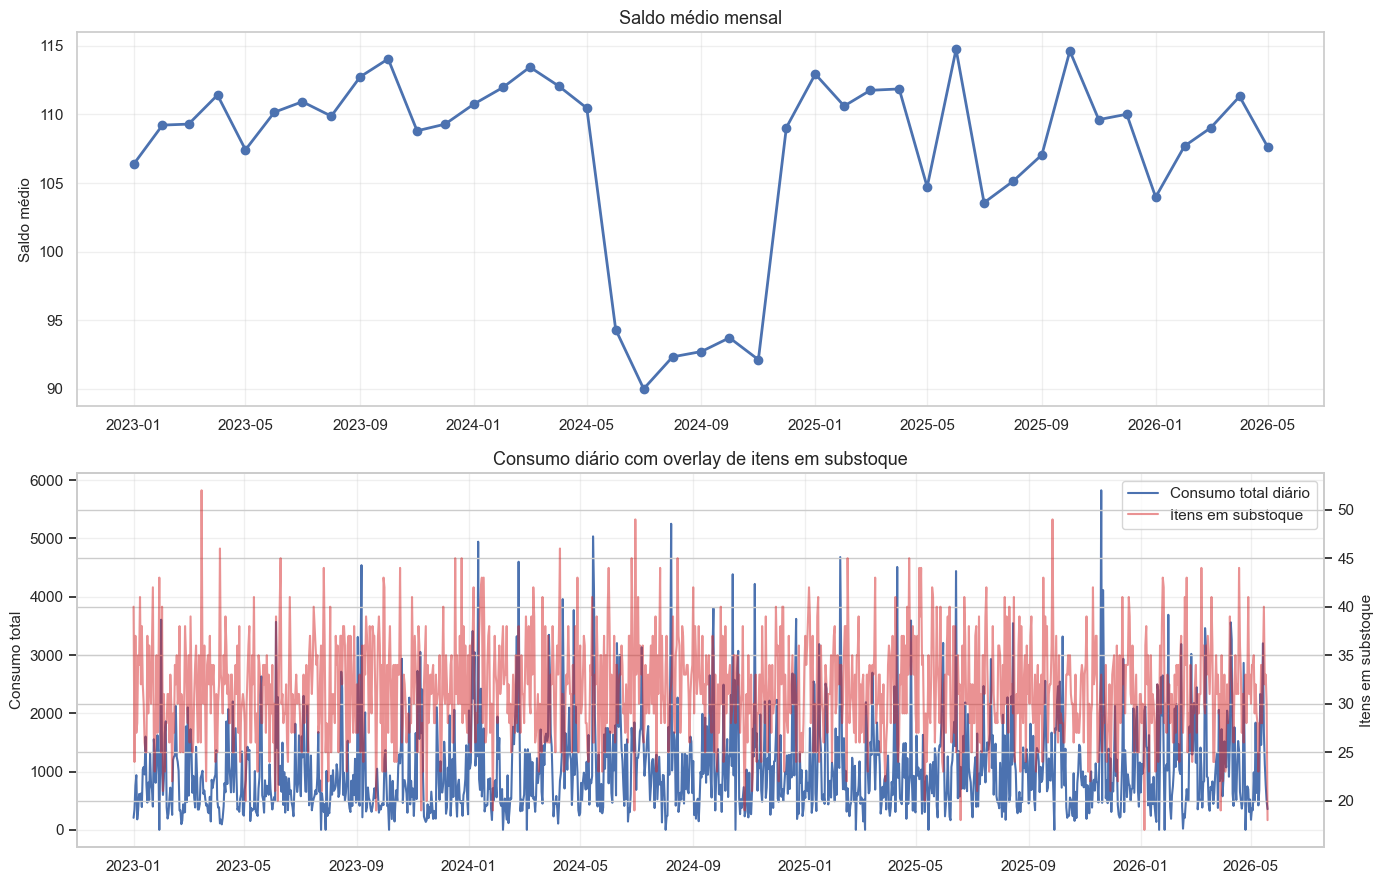

In [3]:
mensal = resumo_mensal.copy()
mensal["periodo"] = pd.to_datetime(
    mensal["year"].astype(str) + "-" + mensal["month"].astype(str).str.zfill(2) + "-01"
)

diario = resumo_diario.sort_values("date").copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

axes[0].plot(mensal["periodo"], mensal["saldo_medio"], marker="o", linewidth=2)
axes[0].set_title("Saldo médio mensal")
axes[0].set_ylabel("Saldo médio")
axes[0].grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(diario["date"], diario["consumo_total"], label="Consumo total diário", linewidth=1.5)
ax2.set_title("Consumo diário com overlay de itens em substoque")
ax2.set_ylabel("Consumo total")
ax2.grid(alpha=0.3)

ax2b = ax2.twinx()
ax2b.plot(
    diario["date"],
    diario["itens_substoque"],
    color="tab:red",
    alpha=0.5,
    label="Itens em substoque",
)
ax2b.set_ylabel("Itens em substoque")

lines_a, labels_a = ax2.get_legend_handles_labels()
lines_b, labels_b = ax2b.get_legend_handles_labels()
ax2.legend(lines_a + lines_b, labels_a + labels_b, loc="upper right")

plt.tight_layout()
plt.show()

## 4. Sazonalidade semanal e mensal

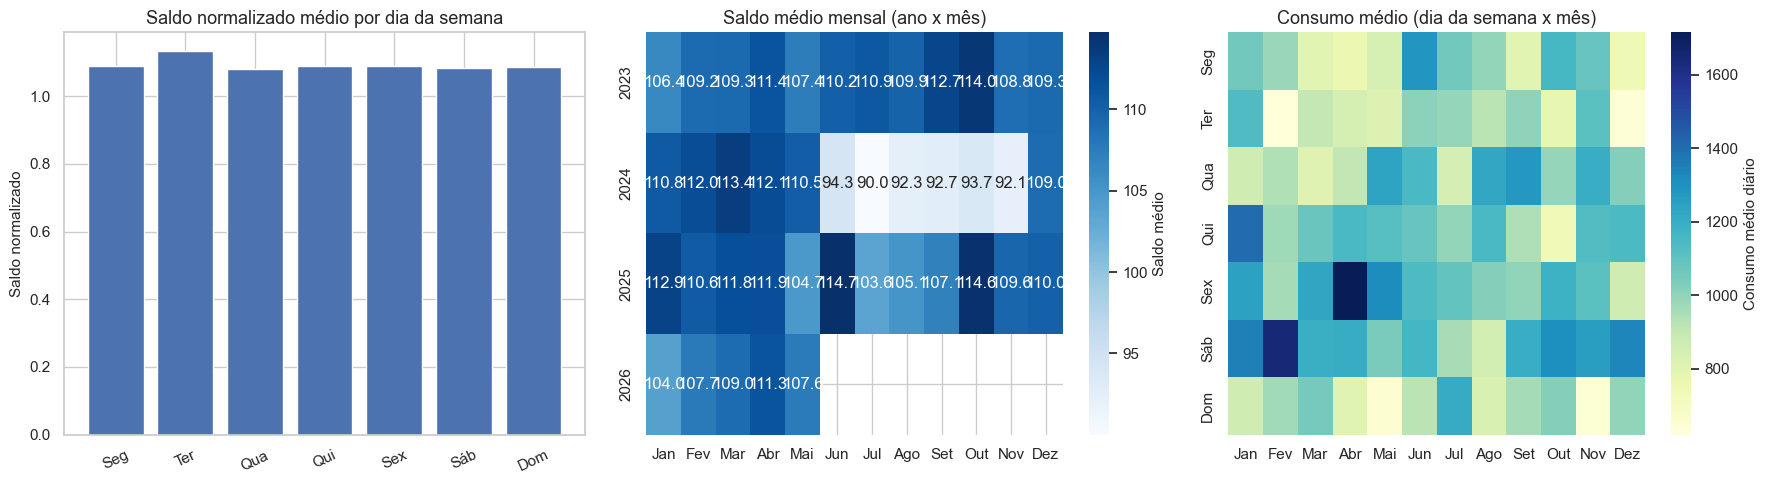

In [4]:
saldo_semana = df.groupby("dia_semana", as_index=False)["saldo_norm"].mean().sort_values("dia_semana")
saldo_semana["dia"] = saldo_semana["dia_semana"].map({i: d for i, d in enumerate(DIAS_PT)})

heat_mensal = resumo_mensal.pivot(index="year", columns="month", values="saldo_medio")
heat_mensal = heat_mensal.reindex(columns=sorted(heat_mensal.columns))
heat_mensal.columns = [MESES_PT[m] for m in heat_mensal.columns]

resumo_tmp = resumo_diario.copy()
resumo_tmp["mes"] = resumo_tmp["date"].dt.month
resumo_tmp["dia_semana"] = resumo_tmp["date"].dt.weekday
heat_semana_mes = resumo_tmp.pivot_table(
    index="dia_semana", columns="mes", values="consumo_total", aggfunc="mean"
).reindex(index=range(7), columns=range(1, 13))
heat_semana_mes.index = DIAS_PT
heat_semana_mes.columns = [MESES_PT[m] for m in heat_semana_mes.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(saldo_semana["dia"], saldo_semana["saldo_norm"], color=sns.color_palette("deep")[0])
axes[0].set_title("Saldo normalizado médio por dia da semana")
axes[0].set_ylabel("Saldo normalizado")
axes[0].tick_params(axis="x", rotation=25)

sns.heatmap(heat_mensal, cmap="Blues", annot=True, fmt=".1f", ax=axes[1], cbar_kws={"label": "Saldo médio"})
axes[1].set_title("Saldo médio mensal (ano x mês)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.heatmap(heat_semana_mes, cmap="YlGnBu", ax=axes[2], cbar_kws={"label": "Consumo médio diário"})
axes[2].set_title("Consumo médio (dia da semana x mês)")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## 5. Distribuição por categoria

C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\1916511212.py:27: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\1916511212.py:27: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()


C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


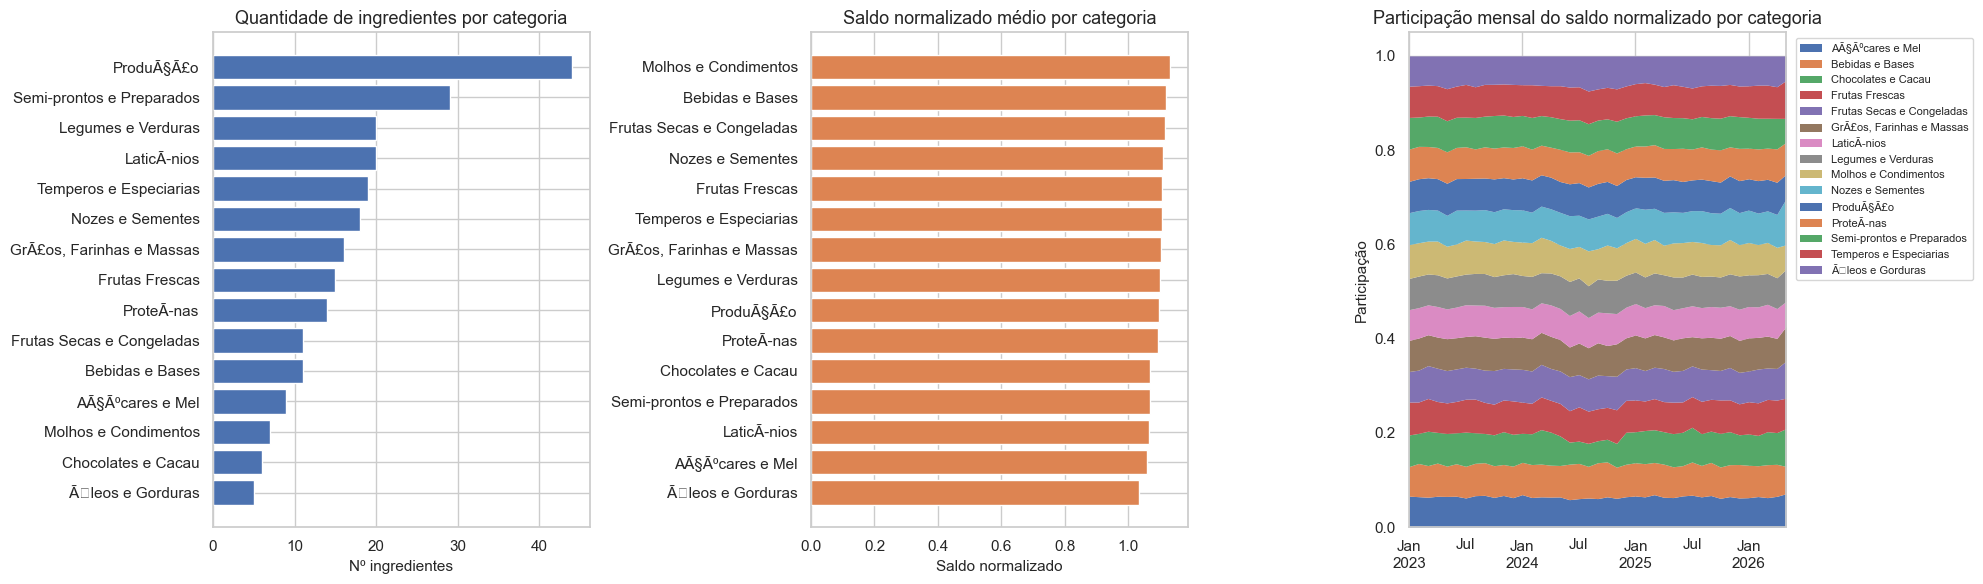

In [5]:
cat_counts = df[["ingredient_id", "categoria"]].drop_duplicates().groupby("categoria")["ingredient_id"].count().sort_values(ascending=True)
cat_norm = df.groupby("categoria", as_index=False)["saldo_norm"].mean().sort_values("saldo_norm", ascending=True)

cat_month = (
    df.groupby(["ano", "mes", "categoria"], as_index=False)["saldo_norm"]
    .mean()
)
cat_month["periodo"] = pd.to_datetime(cat_month["ano"].astype(str) + "-" + cat_month["mes"].astype(str).str.zfill(2) + "-01")
cat_pivot = cat_month.pivot(index="periodo", columns="categoria", values="saldo_norm").fillna(0)
share = cat_pivot.div(cat_pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].barh(cat_counts.index, cat_counts.values, color=sns.color_palette("deep")[0])
axes[0].set_title("Quantidade de ingredientes por categoria")
axes[0].set_xlabel("Nº ingredientes")

axes[1].barh(cat_norm["categoria"], cat_norm["saldo_norm"], color=sns.color_palette("deep")[1])
axes[1].set_title("Saldo normalizado médio por categoria")
axes[1].set_xlabel("Saldo normalizado")

share.plot.area(ax=axes[2], linewidth=0)
axes[2].set_title("Participação mensal do saldo normalizado por categoria")
axes[2].set_ylabel("Participação")
axes[2].set_xlabel("")
axes[2].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)

plt.tight_layout()
plt.show()

## 6. Top ingredientes — saldo e cobertura

C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2986990373.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_saldo, y="ingrediente", x="saldo_medio", ax=axes[0, 0], palette="Blues_r")
C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2986990373.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=maior_cov, y="ingrediente", x="cobertura_dias", ax=axes[0, 1], palette="Greens_r")


C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2986990373.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=menor_cov, y="ingrediente", x="cobertura_dias", ax=axes[1, 0], palette="Oranges_r")


C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2986990373.py:53: UserWarning: Glyph 131 (\x83) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2986990373.py:53: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2986990373.py:53: UserWarning: Glyph 135 (\x87) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2986990373.py:53: UserWarning: Glyph 137 (\x89) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2986990373.py:53: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()


C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 135 (\x87) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 137 (\x89) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


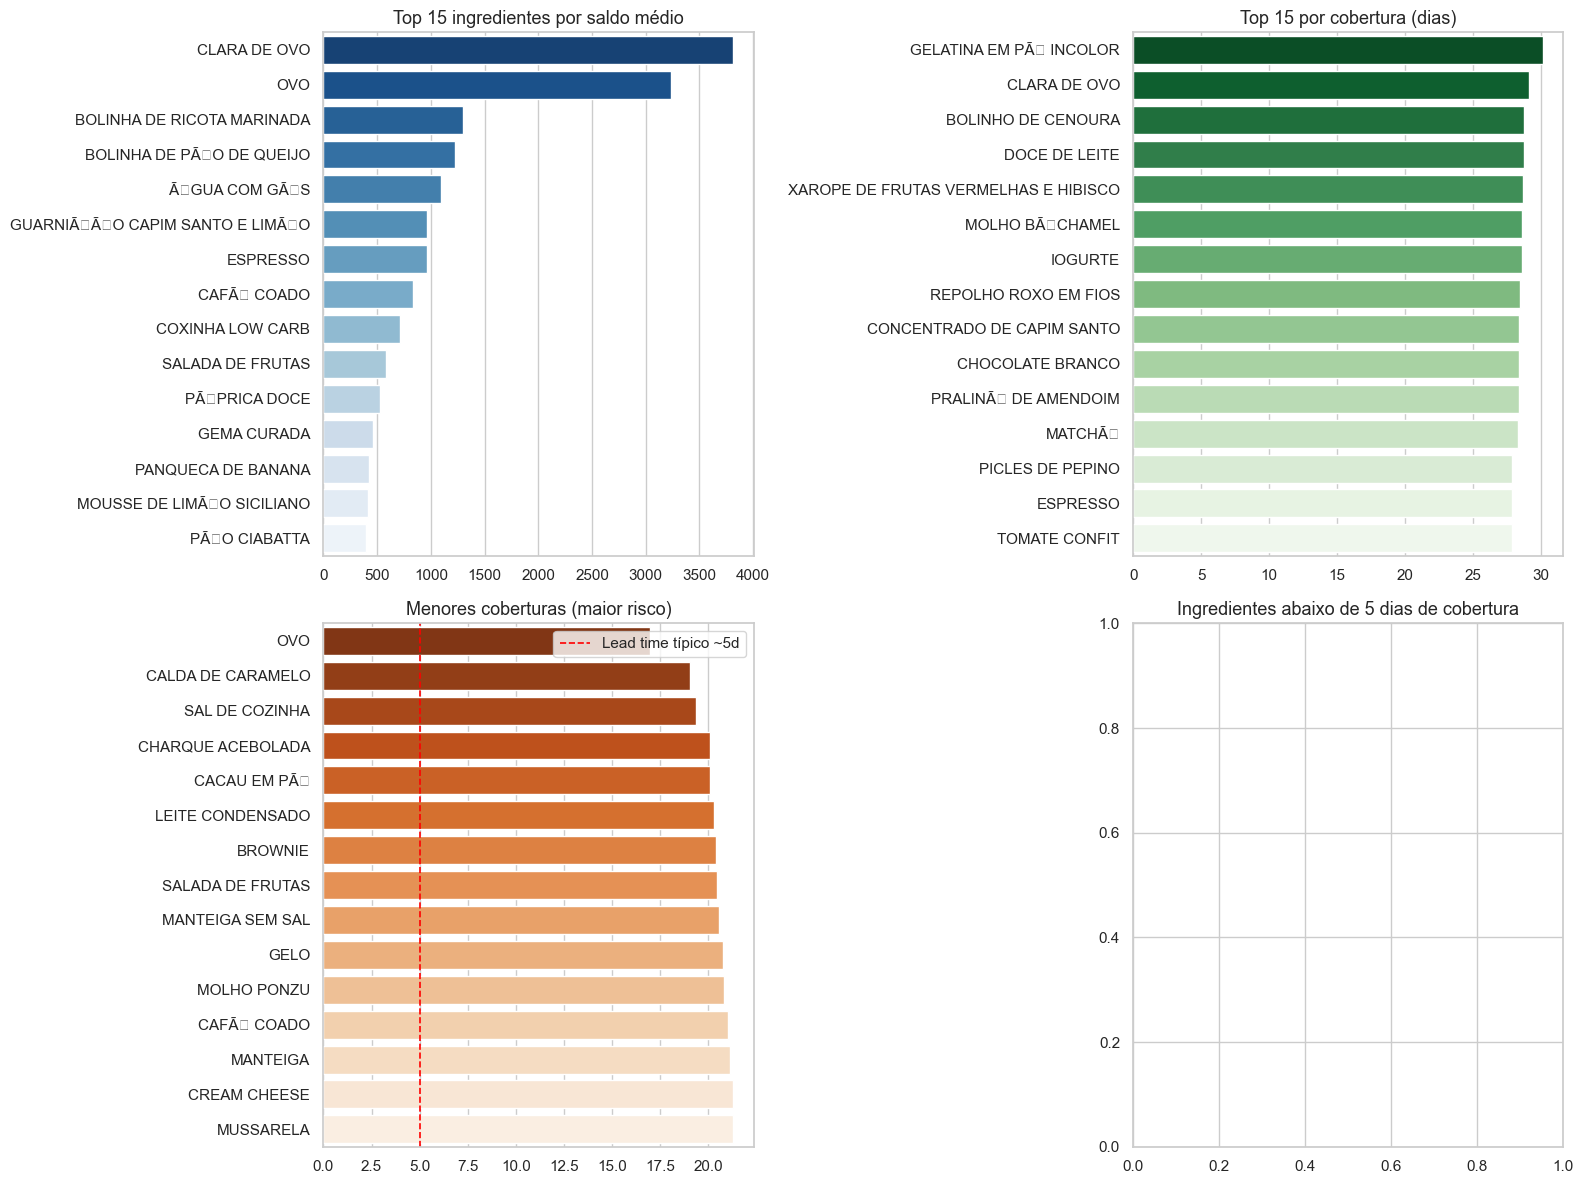

,ingredient_id,ingrediente,unit,cobertura_dias
162,ING0163,OVO,UND,16.967295
180,ING0181,CALDA DE CARAMELO,KG,19.061706
237,ING0238,SAL DE COZINHA,KG,19.365942
154,ING0155,CHARQUE ACEBOLADA,KG,20.094532
26,ING0027,CACAU EM PÃ,KG,20.118948
85,ING0086,LEITE CONDENSADO,KG,20.323829
179,ING0180,BROWNIE,UND,20.406193
56,ING0057,SALADA DE FRUTAS,UND,20.465447
90,ING0091,MANTEIGA SEM SAL,KG,20.551858
17,ING0018,GELO,KG,20.781356


In [6]:
# Consumo derivado (BOM nível 1)
ri_qty = ri.copy()
ri_qty["qty"] = pd.to_numeric(ri_qty["qty"], errors="coerce").fillna(0.0)
finals = receitas[receitas["type"].str.strip().str.upper() == "PRODUTO_FINAL"].copy()
finals["yield_qty"] = pd.to_numeric(finals["yield_qty"], errors="coerce").fillna(1.0).clip(lower=1.0)

bom = ri_qty.merge(finals[["id", "yield_qty"]], left_on="recipe_id", right_on="id", how="inner")
bom["qty_per_unit"] = bom["qty"] / bom["yield_qty"]

v = vendas.copy()
v["data"] = v["date_time"].dt.floor("D")
cons = v.merge(bom[["recipe_id", "ingredient_id", "qty_per_unit"]], on="recipe_id", how="inner")
cons["consumo"] = cons["quantity"] * cons["qty_per_unit"]
consumo_diario = cons.groupby(["data", "ingredient_id"], as_index=False)["consumo"].sum()
consumo_medio = consumo_diario.groupby("ingredient_id", as_index=False)["consumo"].mean().rename(columns={"consumo": "consumo_diario_medio"})

saldo_medio = (
    df.groupby(["ingredient_id", "ingrediente", "unit", "categoria"], as_index=False)["quantity"]
    .mean()
    .rename(columns={"quantity": "saldo_medio"})
)

top_df = saldo_medio.merge(consumo_medio, on="ingredient_id", how="left")
top_df["consumo_diario_medio"] = top_df["consumo_diario_medio"].fillna(0)
top_df["cobertura_dias"] = np.where(top_df["consumo_diario_medio"] > 0, top_df["saldo_medio"] / top_df["consumo_diario_medio"], np.nan)

top_saldo = top_df.nlargest(15, "saldo_medio")
valid_cov = top_df[top_df["cobertura_dias"].notna() & np.isfinite(top_df["cobertura_dias"])].copy()
maior_cov = valid_cov.nlargest(15, "cobertura_dias")
menor_cov = valid_cov.nsmallest(15, "cobertura_dias")
menor_cov_risco = menor_cov[menor_cov["cobertura_dias"] < 5]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=top_saldo, y="ingrediente", x="saldo_medio", ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Top 15 ingredientes por saldo médio")

sns.barplot(data=maior_cov, y="ingrediente", x="cobertura_dias", ax=axes[0, 1], palette="Greens_r")
axes[0, 1].set_title("Top 15 por cobertura (dias)")

sns.barplot(data=menor_cov, y="ingrediente", x="cobertura_dias", ax=axes[1, 0], palette="Oranges_r")
axes[1, 0].set_title("Menores coberturas (maior risco)")
axes[1, 0].axvline(5, color="red", linestyle="--", linewidth=1.2, label="Lead time típico ~5d")
axes[1, 0].legend()

sns.barplot(data=menor_cov_risco.head(15), y="ingrediente", x="cobertura_dias", ax=axes[1, 1], palette="Reds_r")
axes[1, 1].set_title("Ingredientes abaixo de 5 dias de cobertura")

for ax in axes.ravel():
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

menor_cov[["ingredient_id", "ingrediente", "unit", "cobertura_dias"]].head(10)

## 7. Sobrestoque, substoque e ruptura

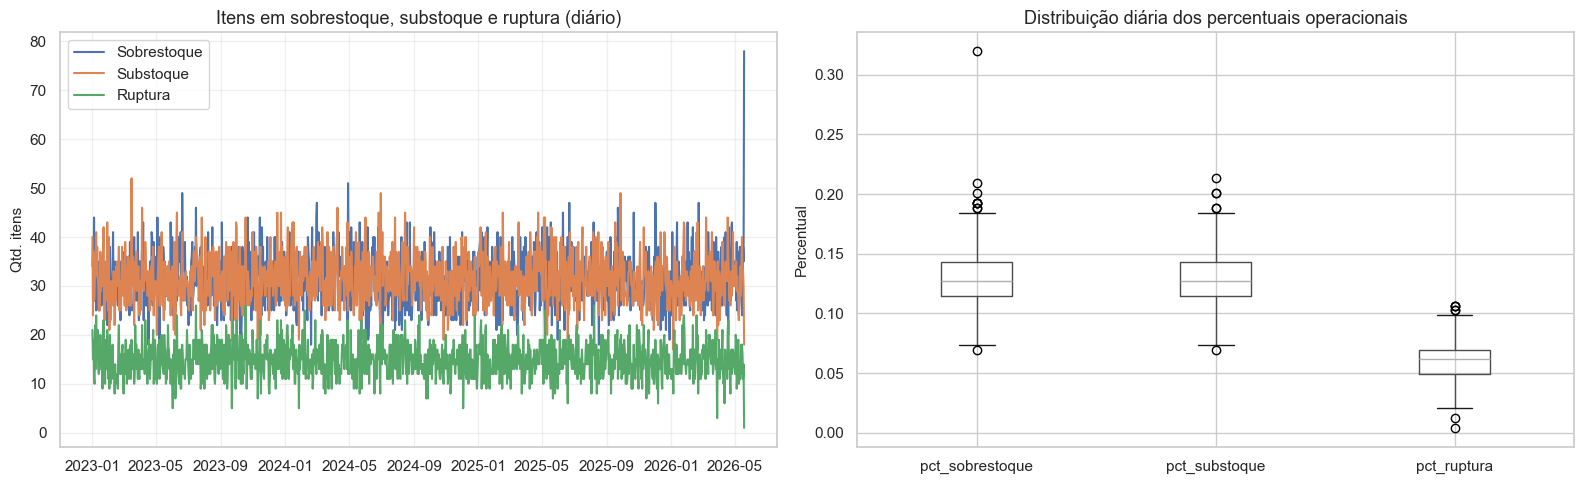

,ingredient_id,ingrediente,unit,ruptura
179,ING0180,BROWNIE,UND,32.6%
161,ING0162,GEMA CURADA,UND,19.9%
144,ING0145,SEMENTE DE ABÃBORA,KG,19.8%
222,ING0223,CANELA,KG,19.7%
66,ING0067,FARINHA PANKO,KG,19.5%
162,ING0163,OVO,UND,19.4%
97,ING0098,ACELGA,KG,19.2%
54,ING0055,MIX DE FRUTAS VERMELHAS CONGELADAS,KG,19.1%
198,ING0199,GRÃO DE BICO COZIDO,KG,19.0%
49,ING0050,CRANBERRY SECO,KG,18.8%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rd = resumo_diario.sort_values("date").copy()
axes[0].plot(rd["date"], rd["itens_sobrestoque"], label="Sobrestoque")
axes[0].plot(rd["date"], rd["itens_substoque"], label="Substoque")
axes[0].plot(rd["date"], rd["itens_ruptura"], label="Ruptura")
axes[0].set_title("Itens em sobrestoque, substoque e ruptura (diário)")
axes[0].set_ylabel("Qtd. itens")
axes[0].legend()
axes[0].grid(alpha=0.3)

status_pct = pd.DataFrame(
    {
        "pct_sobrestoque": rd["itens_sobrestoque"] / df["ingredient_id"].nunique(),
        "pct_substoque": rd["itens_substoque"] / df["ingredient_id"].nunique(),
        "pct_ruptura": rd["itens_ruptura"] / df["ingredient_id"].nunique(),
    }
)
status_pct.boxplot(ax=axes[1])
axes[1].set_title("Distribuição diária dos percentuais operacionais")
axes[1].set_ylabel("Percentual")

plt.tight_layout()
plt.show()

# Top 10 ingredientes por % de dias em ruptura
rupt = (
    df.assign(ruptura=(df["quantity"] <= 1e-9).astype(int))
    .groupby(["ingredient_id", "ingrediente", "unit"], as_index=False)["ruptura"]
    .mean()
    .sort_values("ruptura", ascending=False)
    .head(10)
)
rupt["ruptura"] = (rupt["ruptura"] * 100).round(1).astype(str) + "%"
rupt

## 8. Impacto da indisponibilidade de produto

C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2772582412.py:96: UserWarning: Glyph 135 (\x87) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2772582412.py:96: UserWarning: Glyph 154 (\x9a) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\2772582412.py:96: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()


C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 135 (\x87) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 154 (\x9a) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


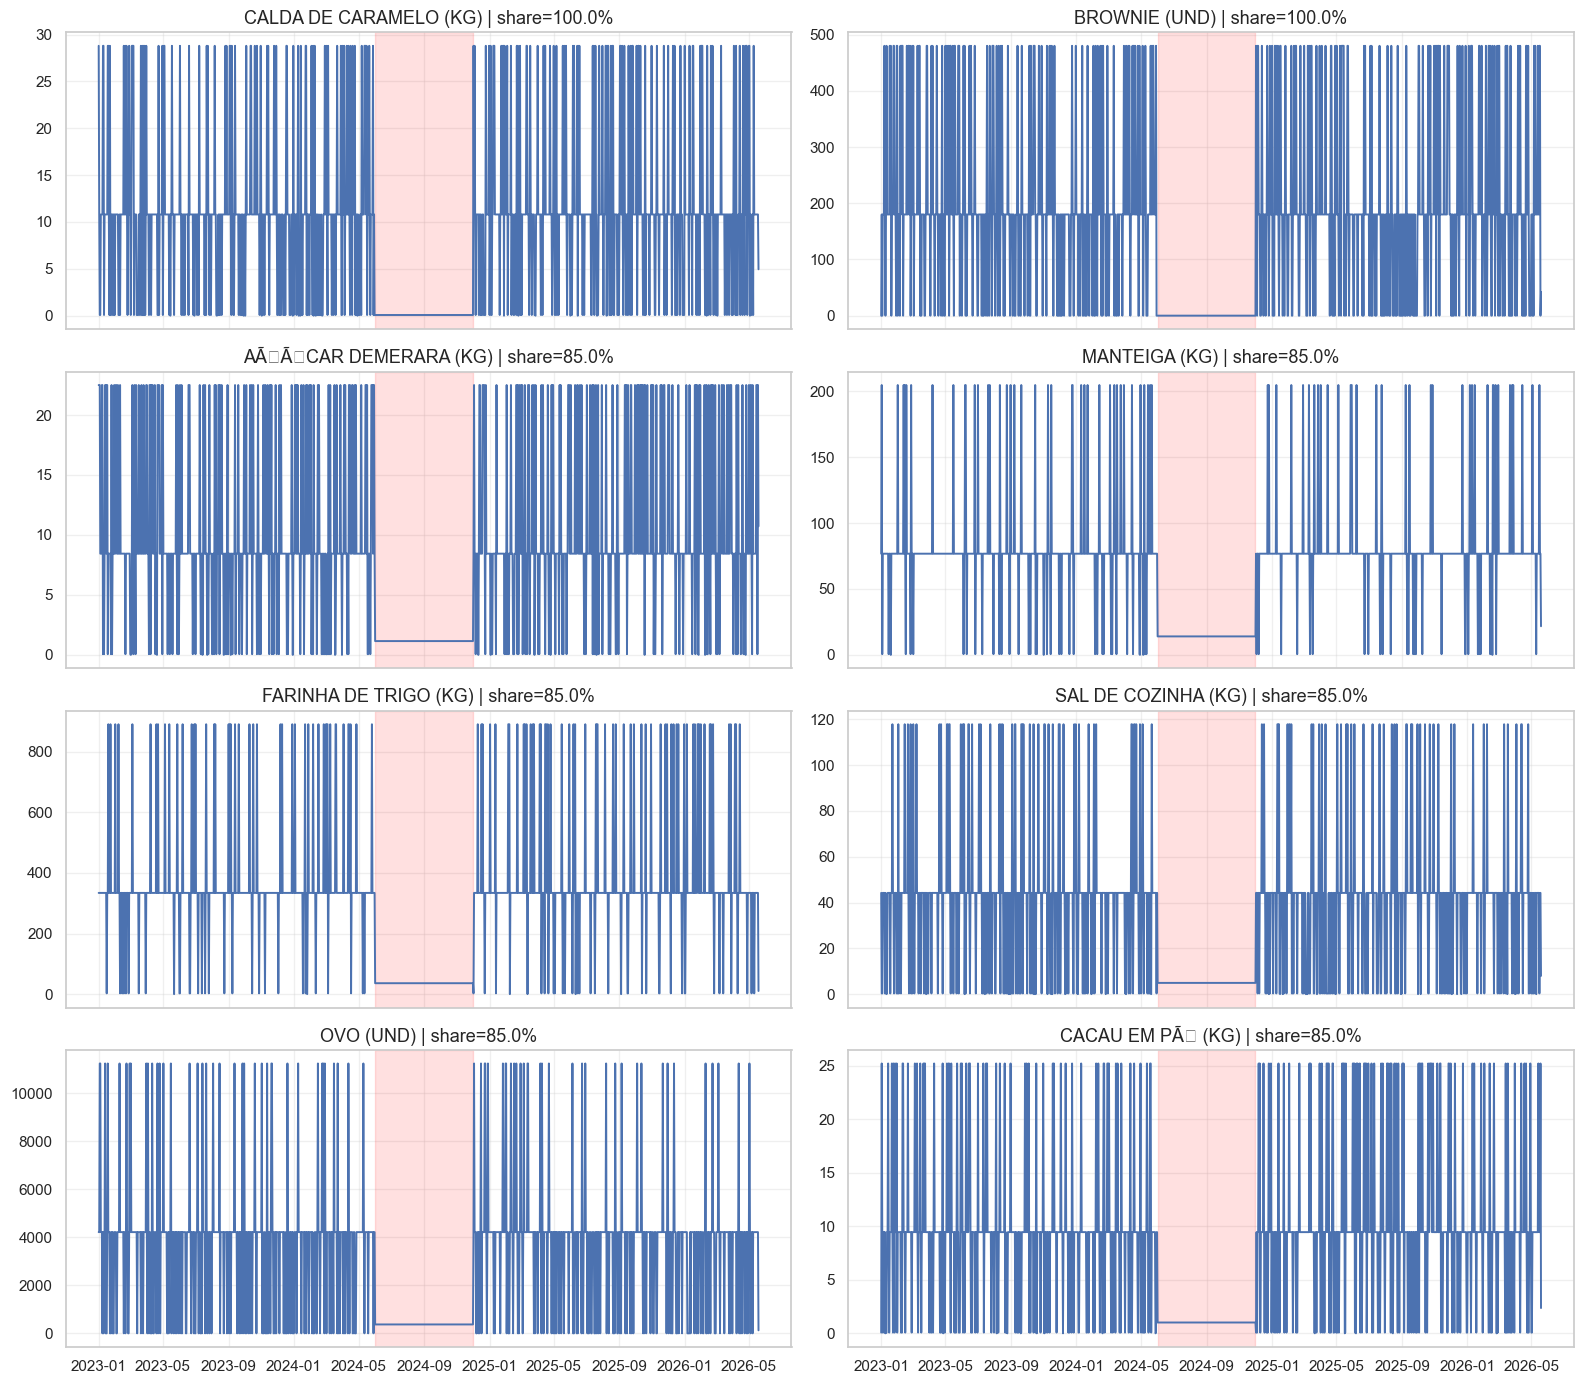

In [8]:
finals = receitas[receitas["type"].str.strip().str.upper() == "PRODUTO_FINAL"].copy()
finals["id"] = finals["id"].astype(str)
finals["name_u"] = finals["name"].astype(str).str.upper()

# Resolve recipe_ids indisponíveis via match em id ou substring de nome
paused_ids = set()
for _, row in indisp.iterrows():
    token = str(row["match"]).strip()
    if not token:
        continue
    if token in set(finals["id"]):
        paused_ids.add(token)
    else:
        mask = finals["name_u"].str.contains(token.upper(), na=False)
        paused_ids.update(finals.loc[mask, "id"].tolist())

ri_qty = ri.copy()
ri_qty["qty"] = pd.to_numeric(ri_qty["qty"], errors="coerce").fillna(0.0)

# BOM nível 1
finals_tmp = finals.copy()
finals_tmp["yield_qty"] = pd.to_numeric(finals_tmp["yield_qty"], errors="coerce").fillna(1.0).clip(lower=1.0)
bom1 = ri_qty.merge(finals_tmp[["id", "yield_qty"]], left_on="recipe_id", right_on="id", how="inner")
bom1["qty_per_unit"] = bom1["qty"] / bom1["yield_qty"]

# BOM nível 2 via semi-acabados
prod = receitas[receitas["type"].str.strip().str.upper() == "PRODUCAO"].copy()
prod = prod.dropna(subset=["output_ingredient_id"]).copy()
prod["output_ingredient_id"] = prod["output_ingredient_id"].astype(str)
prod["yield_qty"] = pd.to_numeric(prod["yield_qty"], errors="coerce").fillna(1.0).clip(lower=1.0)

prod_bom = ri_qty.merge(prod[["id", "yield_qty", "output_ingredient_id"]], left_on="recipe_id", right_on="id", how="inner")
prod_bom["qty_per_yield"] = prod_bom["qty"] / prod_bom["yield_qty"]

semi_lookup = {}
for out_id, grp in prod_bom.groupby("output_ingredient_id"):
    semi_lookup[out_id] = [(str(r["ingredient_id"]), float(r["qty_per_yield"])) for _, r in grp.iterrows()]

# Share de impacto por ingrediente
sales_total = vendas.groupby("recipe_id", as_index=False)["quantity"].sum()
base = bom1[["recipe_id", "ingredient_id", "qty_per_unit"]].copy()
base["recipe_id"] = base["recipe_id"].astype(str)
base["ingredient_id"] = base["ingredient_id"].astype(str)

direct_total = sales_total.merge(base, on="recipe_id", how="inner")
direct_total["cons"] = direct_total["quantity"] * direct_total["qty_per_unit"]
total_by_ing = direct_total.groupby("ingredient_id", as_index=False)["cons"].sum().rename(columns={"cons": "total"})

paused_sales = sales_total[sales_total["recipe_id"].astype(str).isin(paused_ids)].copy()
paused_direct = paused_sales.merge(base, on="recipe_id", how="inner")
paused_direct["cons"] = paused_direct["quantity"] * paused_direct["qty_per_unit"]
paused_by_ing = paused_direct.groupby("ingredient_id", as_index=False)["cons"].sum().rename(columns={"cons": "paused"})

impact = total_by_ing.merge(paused_by_ing, on="ingredient_id", how="left")
impact["paused"] = impact["paused"].fillna(0)
impact["share"] = np.where(impact["total"] > 0, impact["paused"] / impact["total"], 0)

# Expansão para folhas quando ingrediente direto é semi-acabado
for semi_id, leaves in semi_lookup.items():
    share_semi = float(impact.loc[impact["ingredient_id"] == semi_id, "share"].max()) if (impact["ingredient_id"] == semi_id).any() else 0.0
    if share_semi <= 0:
        continue
    for leaf_id, _ in leaves:
        idx = impact[impact["ingredient_id"] == leaf_id].index
        if len(idx):
            impact.loc[idx, "share"] = np.maximum(impact.loc[idx, "share"], share_semi * 0.85)

impact = impact.merge(df[["ingredient_id", "ingrediente", "unit"]].drop_duplicates(), on="ingredient_id", how="left")
impact = impact.sort_values("share", ascending=False)

if indisp.empty:
    print("Nenhum período de indisponibilidade informado.")
else:
    jan_ini = indisp["data_inicio"].min()
    jan_fim = indisp["data_fim"].max()
    top_imp = impact[impact["share"] > 0].head(8)

    fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
    axes = axes.ravel()

    for i, (_, row) in enumerate(top_imp.iterrows()):
        sub = (
            df[df["ingredient_id"] == row["ingredient_id"]]
            .groupby("data", as_index=False)["quantity"]
            .mean()
            .sort_values("data")
        )
        axes[i].plot(sub["data"], sub["quantity"], linewidth=1.4)
        axes[i].axvspan(jan_ini, jan_fim, color="red", alpha=0.12)
        axes[i].set_title(f"{row['ingrediente']} ({row['unit']}) | share={row['share']:.1%}")
        axes[i].grid(alpha=0.3)

    for j in range(len(top_imp), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    comparativo = []
    top15 = impact[impact["share"] > 0].head(15)
    for _, row in top15.iterrows():
        sub = df[df["ingredient_id"] == row["ingredient_id"]][["data", "quantity"]]
        dentro = sub[(sub["data"] >= jan_ini) & (sub["data"] <= jan_fim)]["quantity"].mean()
        fora = sub[(sub["data"] < jan_ini) | (sub["data"] > jan_fim)]["quantity"].mean()
        delta = ((dentro / fora) - 1) * 100 if pd.notna(fora) and fora > 0 else np.nan
        comparativo.append(
            {
                "ingredient_id": row["ingredient_id"],
                "ingrediente": row["ingrediente"],
                "share": row["share"],
                "saldo_medio_dentro_janela": dentro,
                "saldo_medio_fora_janela": fora,
                "delta_%": delta,
            }
        )

    comp_df = pd.DataFrame(comparativo).sort_values("share", ascending=False)
    comp_df

## 9. Coerência consumo x estoque

C:\Users\thomaz.lima_visagio\AppData\Local\Temp\ipykernel_15864\3637025191.py:30: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()


C:\CESAR\Projetos-6-Saltim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


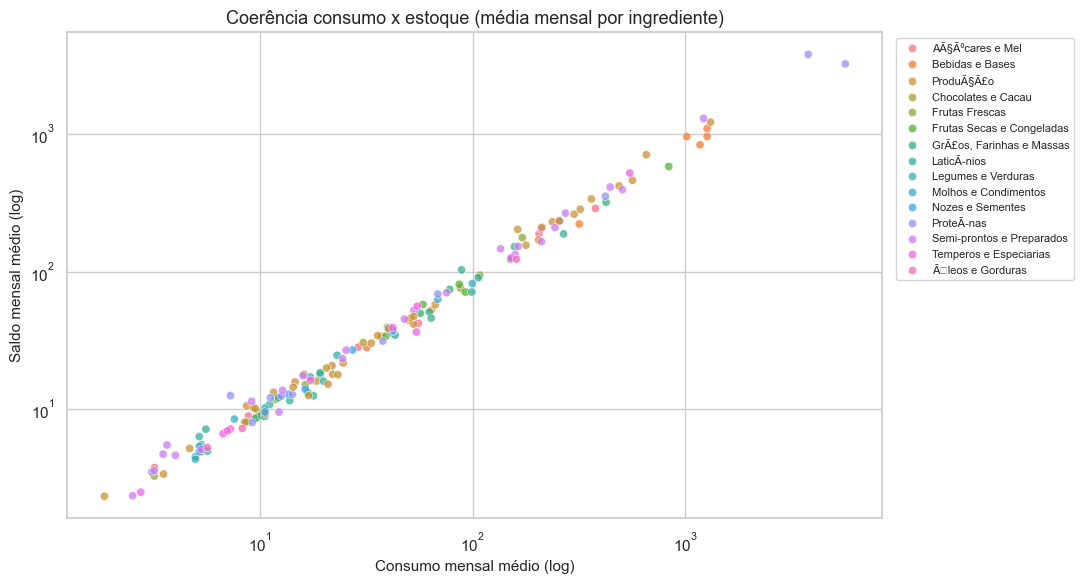

Correlação Spearman: 0.995
Correlação Pearson: 0.963


,ingredient_id,categoria,saldo_mensal_medio,consumo_mensal_medio
104,ING0163,ProteÃ­nas,3247.318653,5673.829268
100,ING0159,ProteÃ­nas,3804.945859,3798.365854
117,ING0177,ProduÃ§Ã£o,1222.887335,1318.658537
16,ING0023,Bebidas e Bases,1097.461515,1270.609756
12,ING0019,Bebidas e Bases,963.651739,1270.609756
118,ING0178,Semi-prontos e Preparados,1301.801667,1222.439024
6,ING0010,Bebidas e Bases,836.833549,1176.341463
10,ING0015,Bebidas e Bases,959.787769,1019.463415
38,ING0057,Frutas Secas e Congeladas,582.289491,838.219512
125,ING0185,ProduÃ§Ã£o,708.915784,656.951220


In [9]:
cons["ano"] = cons["date_time"].dt.year
cons["mes"] = cons["date_time"].dt.month
cons_mensal = cons.groupby(["ano", "mes", "ingredient_id"], as_index=False)["consumo"].sum()
cons_mensal_tot = cons_mensal.groupby("ingredient_id", as_index=False)["consumo"].mean().rename(columns={"consumo": "consumo_mensal_medio"})

saldo_mensal = (
    df.groupby(["ano", "mes", "ingredient_id", "categoria"], as_index=False)["quantity"]
    .mean()
)
saldo_mensal_tot = saldo_mensal.groupby(["ingredient_id", "categoria"], as_index=False)["quantity"].mean().rename(columns={"quantity": "saldo_mensal_medio"})

coer = saldo_mensal_tot.merge(cons_mensal_tot, on="ingredient_id", how="inner")
coer = coer[(coer["consumo_mensal_medio"] > 0) & (coer["saldo_mensal_medio"] > 0)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=coer,
    x="consumo_mensal_medio",
    y="saldo_mensal_medio",
    hue="categoria",
    alpha=0.75,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Coerência consumo x estoque (média mensal por ingrediente)")
ax.set_xlabel("Consumo mensal médio (log)")
ax.set_ylabel("Saldo mensal médio (log)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

spearman = coer["consumo_mensal_medio"].rank().corr(coer["saldo_mensal_medio"].rank())
pearson = coer["consumo_mensal_medio"].corr(coer["saldo_mensal_medio"])
print(f"Correlação Spearman: {spearman:.3f}")
print(f"Correlação Pearson: {pearson:.3f}")
coer.sort_values("consumo_mensal_medio", ascending=False).head(10)